C:\Users\TahaS\AppData\Local\Temp\ipykernel_8108\3564442153.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  Graph = sns.distplot(data['Selling_Price'])


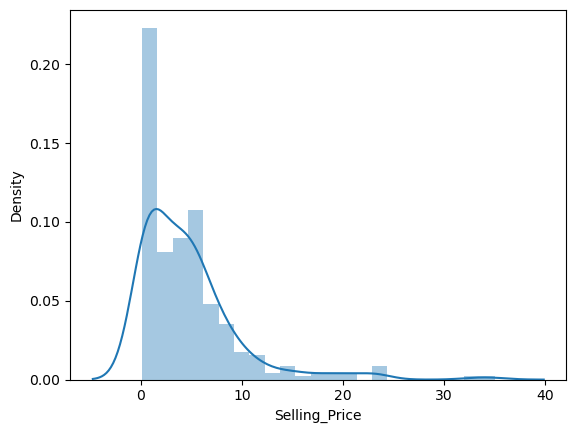

In [38]:
#read a csv file related to cars
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('car data.csv')
data = data.drop(columns = 'Unnamed: 1')
features = data['Selling_Price'].corr(data['Present_Price'])
#results in 0.8790 though linear but isnt perfect (clumps form) so we will make it perfect then use them in gradient descent and in a linear plot
Graph = sns.distplot(data['Selling_Price'])
# selling price data is positively skewed thus also present price

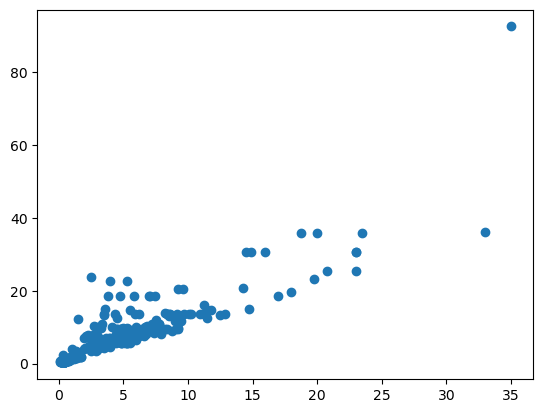

In [39]:
#if we show this graph in a scatter plot
plt.scatter(data['Selling_Price'], data['Present_Price'])

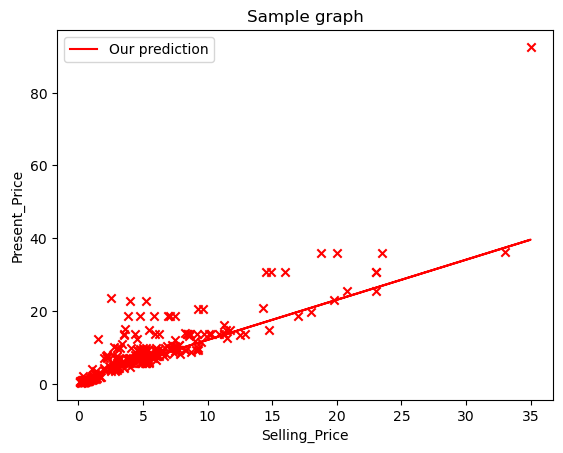

In [45]:
#performing gradient descent without the fix
# clumps shown at first 
import numpy as np
import matplotlib.pyplot as plt

x_train = data['Selling_Price']
y_train = data['Present_Price']




def gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        dj_dw_i = ((w*x[i]+b)-y[i])*x[i]
        dj_db_i = (w*x[i]+b) - y[i]
        dj_db+=dj_db_i
        dj_dw+=dj_dw_i
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, alpha,  iteration, comGradient):
    w = w_in
    b = b_in
    for i in range(iteration):
        dj_dw, dj_db = comGradient(x, y, w, b)
        b = b - alpha*dj_db
        w = b - alpha*dj_dw

    return w, b
        
        
w_in = 0
b_in = 0
ITS = 3000
alp = 0.0001
w_final = 0
b_final = 0

w_final, b_final = gradient_descent(x_train, y_train, w_in, b_in, alp, ITS, gradient)
def compute_model(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w*x[i]+b
    return f_wb
tmp_fwb = compute_model(x_train, w_final, b_final)
plt.plot(x_train, tmp_fwb, c='r', label = "Our prediction")
plt.scatter(x_train, y_train, marker = 'x', c="r")
plt.title("Sample graph")
plt.ylabel("Present_Price")
plt.xlabel("Selling_Price")

plt.legend()
plt.show()
    


C:\Users\TahaS\AppData\Local\Temp\ipykernel_8108\384835624.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  Graph = sns.distplot(Selling_price)


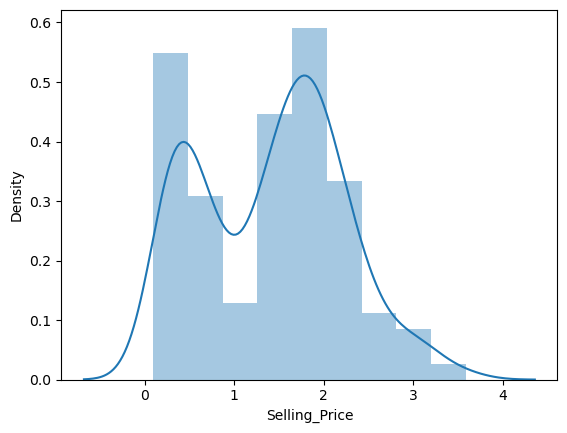

In [61]:
#fixing part( performing log transformation)


Selling_Price = np.log1p(data['Selling_Price'])
Present_Price = np.log1p(data['Present_Price'])
#checking skewness
Graph = sns.distplot(Selling_price)

#plt.scatter(Selling_price, Present_Price)  (if you want to see how much less scattered it is now than before)
#data is now well more distributed, allowing for better results in gradient descent


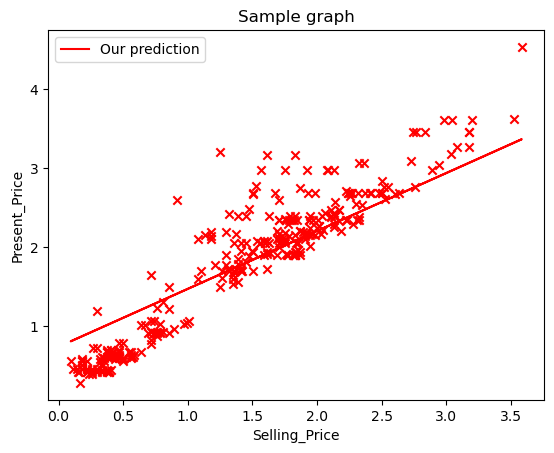

In [44]:
#performing gradient descent with the fix
 
import numpy as np
import matplotlib.pyplot as plt

x_train = Selling_Price
y_train = Present_Price




def gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        dj_dw_i = ((w*x[i]+b)-y[i])*x[i]
        dj_db_i = (w*x[i]+b) - y[i]
        dj_db+=dj_db_i
        dj_dw+=dj_dw_i
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, alpha,  iteration, comGradient):
    w = w_in
    b = b_in
    for i in range(iteration):
        dj_dw, dj_db = comGradient(x, y, w, b)
        b = b - alpha*dj_db
        w = b - alpha*dj_dw

    return w, b
        
        
w_in = 0
b_in = 0
ITS = 3000
alp = 0.002 #alpha has been changed (how big a step is taken)
w_final = 0
b_final = 0

w_final, b_final = gradient_descent(x_train, y_train, w_in, b_in, alp, ITS, gradient)
def compute_model(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w*x[i]+b
    return f_wb
tmp_fwb = compute_model(x_train, w_final, b_final)
plt.plot(x_train, tmp_fwb, c='r', label = "Our prediction")
plt.scatter(x_train, y_train, marker = 'x', c="r")
plt.title("Sample graph")
plt.ylabel("Present_Price")
plt.xlabel("Selling_Price")

plt.legend()
plt.show()
  


In [ ]:
#thus our regression line has become more accurate and data points arent much clustered than before, they are also showing a better linear relationship than before

In [90]:
#now lets view our data again
data.head()
#we can use value counts to see the most common one but to calculate mean we use one-hot encoding
data['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [74]:
# we will perform one-hot encoding on FueL_Type to see the most used one 
data_encoded = pd.get_dummies(data, columns = ['Fuel_Type'])
data_encoded

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Seller_Type,Transmission,Owner,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,ritz,3.35,5.59,27000,Dealer,Manual,0,False,False,True
1,sx4,4.75,9.54,43000,Dealer,Manual,0,False,True,False
2,ciaz,7.25,9.85,6900,Dealer,Manual,0,False,False,True
3,wagon r,2.85,4.15,5200,Dealer,Manual,0,False,False,True
4,swift,4.60,6.87,42450,Dealer,Manual,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...
296,city,9.50,11.60,33988,Dealer,Manual,0,False,True,False
297,brio,4.00,5.90,60000,Dealer,Manual,0,False,False,True
298,city,3.35,11.00,87934,Dealer,Manual,0,False,False,True
299,city,11.50,12.50,9000,Dealer,Manual,0,False,True,False


In [95]:
#now we can use mean to see which is more used
Encoded_Values = pd.get_dummies(data_encoded[['Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol' ]])

# Calculate mean
mean_values = Encoded_Values.mean()

print(mean_values*100)
#fuel type petrol is used the most, this will allow us to see the percentage of feature occupied by specific fuel type
#now why not use value counts directly to see, with the help of one-hot encoding we can find correlations 

Fuel_Type_CNG        0.664452
Fuel_Type_Diesel    19.933555
Fuel_Type_Petrol    79.401993
dtype: float64


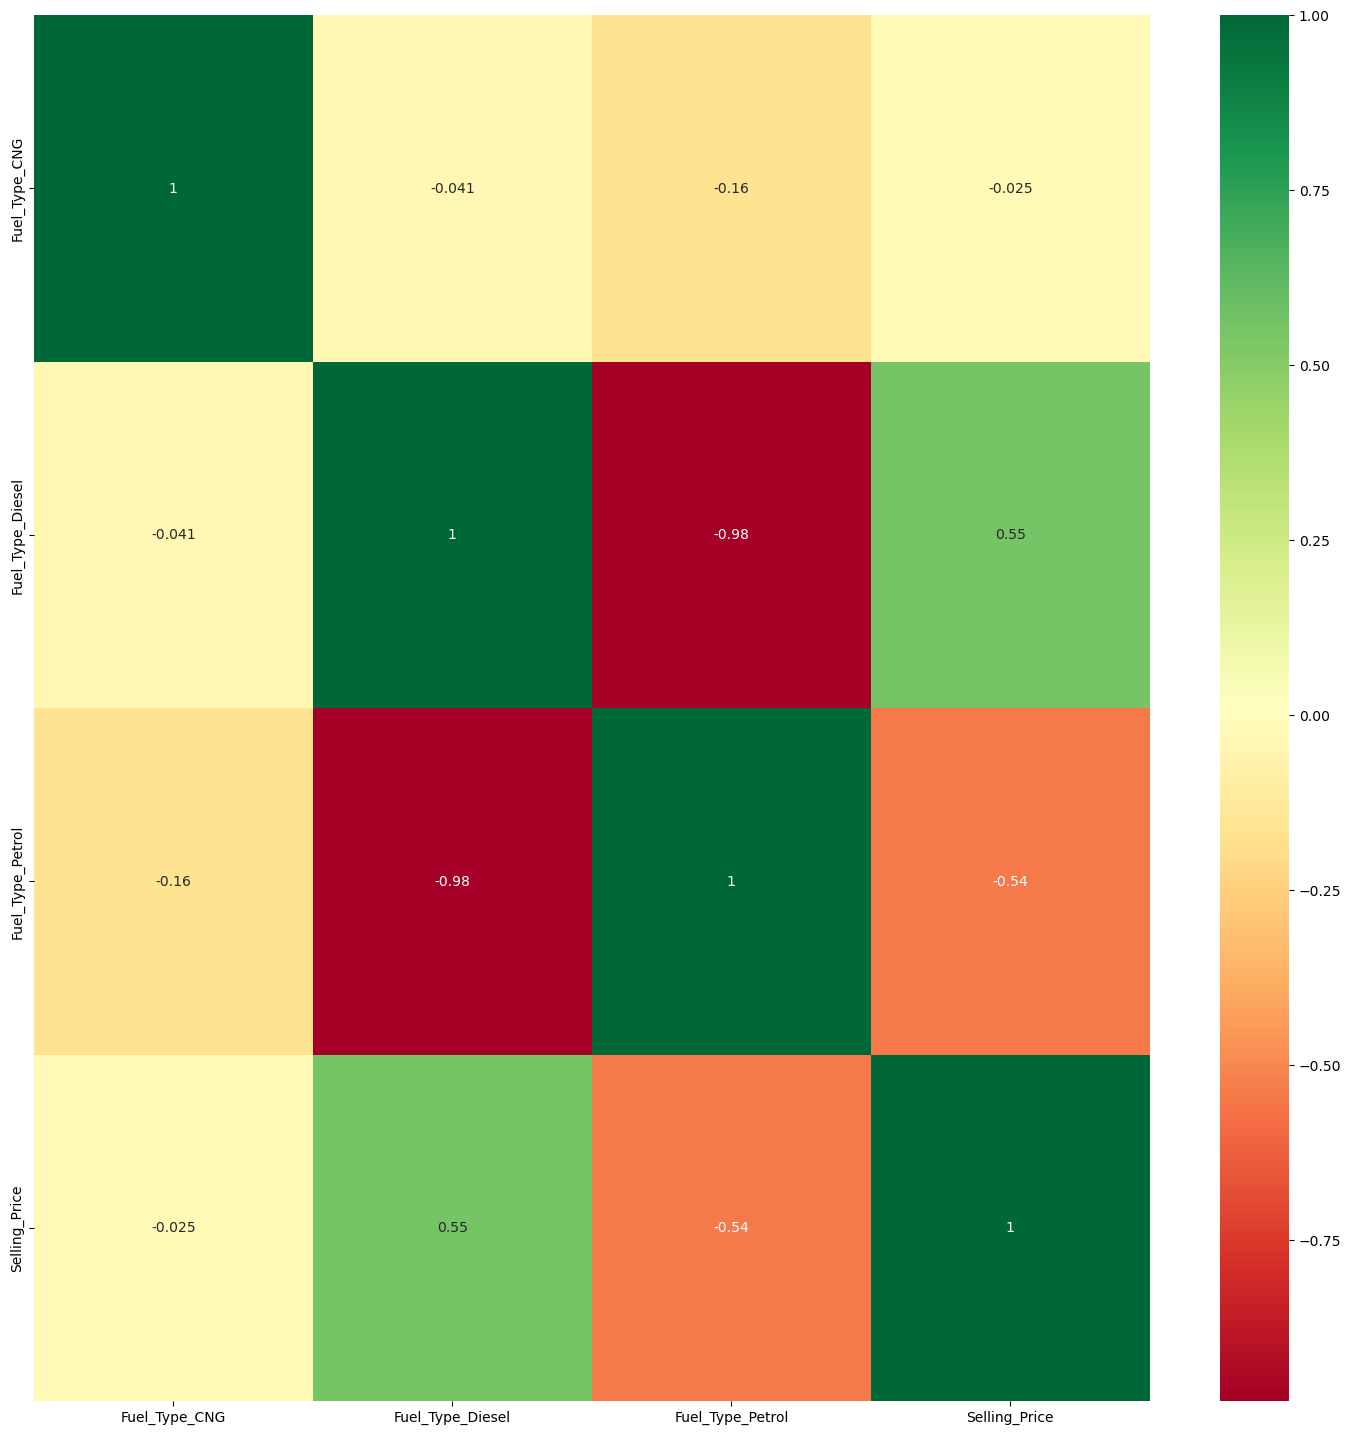

In [101]:
Encoded_Values["Selling_Price"] = data['Selling_Price']#added selling price as we will see correlation using heat map from sea born
plt.figure(figsize=(18, 18))
sns.heatmap(Encoded_Values.corr(),annot=True,cmap='RdYlGn')
plt.show()

In [ ]:
#as you can see selling price correlates the best with fuel type diesel which indicates prices rosen since diesel is expensive

In [102]:
data.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [107]:
# making a profit percentage column
data['Profit_Percentage'] = (((data['Present_Price'] - data['Selling_Price'])/data['Selling_Price'])*100).round(2)
data.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Profit,Profit_Percentage
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,224.0,66.87
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,479.0,100.84
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,260.0,35.86
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,130.0,45.61
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,227.0,49.35
